In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv('/content/crime_dataset_india-1.csv')

In [21]:
df.head()


/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Report Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed
0,1,02-01-2020 00:00,01-01-2020 00:00,01-01-2020 01:11,Ahmedabad,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,No,NaN
1,2,01-01-2020 19:00,01-01-2020 01:00,01-01-2020 06:26,Chennai,128,HOMICIDE,37,M,Poison,Other Crime,9,No,NaN
2,3,02-01-2020 05:00,01-01-2020 02:00,01-01-2020 14:30,Ludhiana,271,KIDNAPPING,48,F,Blunt Object,Other Crime,15,No,NaN
3,4,01-01-2020 05:00,01-01-2020 03:00,01-01-2020 14:46,Pune,170,BURGLARY,49,F,Firearm,Other Crime,1,Yes,29-04-2020 05:00
4,5,01-01-2020 21:00,01-01-2020 04:00,01-01-2020 16:51,Pune,421,VANDALISM,30,F,Other,Other Crime,18,Yes,08-01-2020 21:00


UNIVARIATE ANALYSIS

1.City-wise Crime Count

In [22]:
df['City'].value_counts()

,count
City,
Delhi,87
Mumbai,75
Bangalore,54
Chennai,48
Kolkata,47
Pune,45
Hyderabad,43
Jaipur,32
Ahmedabad,30


2.City-wise Crime Graph

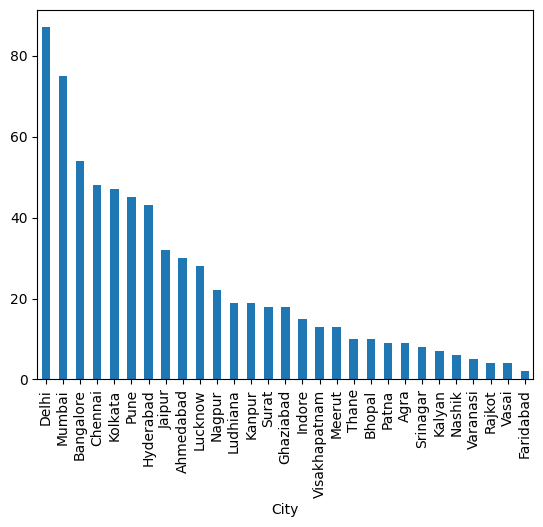

In [14]:
df['City'].value_counts().plot(kind='bar')
plt.show()

3. Crime Domain Count

In [23]:
df['Crime Domain'].value_counts()

,count
Crime Domain,
Other Crime,409
Violent Crime,197
Fire Accident,64
Traffic Fatality,30


4.Crime Domain Graph

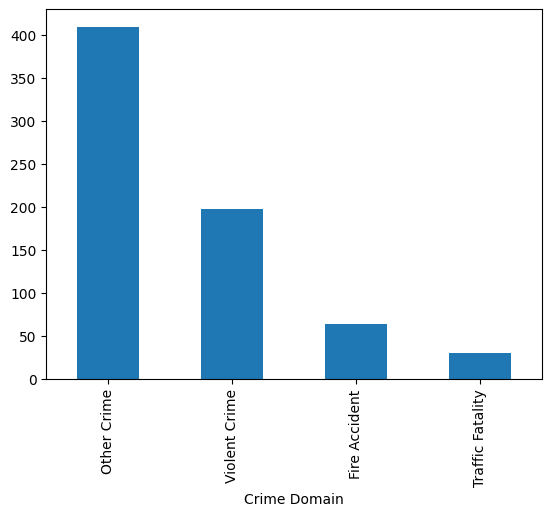

In [24]:
df['Crime Domain'].value_counts().plot(kind='bar')
plt.show()

5.Victim Gender Count

In [ ]:
df['Victim Gender'].value_counts()

,count
Victim Gender,
F,481
M,216
X,3


6.Gender Pie Chart

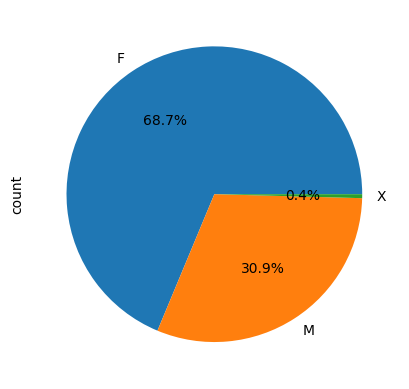

In [16]:
df['Victim Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()

7.Histogram

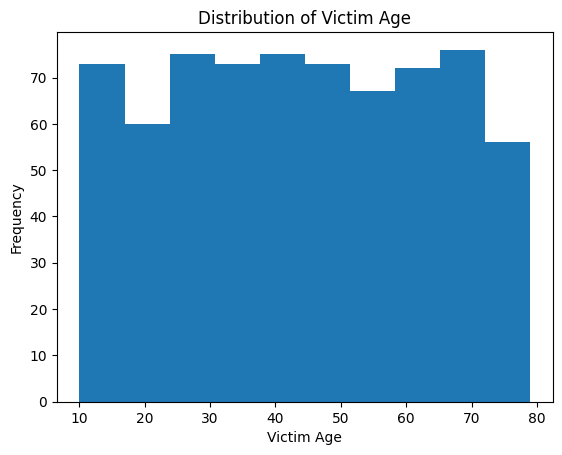

In [ ]:
df['Victim Age'].plot(kind='hist', bins=10)
plt.xlabel("Victim Age")
plt.title("Distribution of Victim Age")
plt.show()

BIVARIATE ANALYSIS

1.City-wise Crime Distribution

In [ ]:
df.groupby('City')['Report Number'].count()

,Report Number
City,
Agra,9
Ahmedabad,30
Bangalore,54
Bhopal,10
Chennai,48
Delhi,87
Faridabad,2
Ghaziabad,18
Hyderabad,43


2.Crime Domain-wise Victim Age Analysis

In [29]:
df.groupby('Crime Domain')['Victim Age'].mean()


,Victim Age
Crime Domain,
Fire Accident,42.937500
Other Crime,43.310513
Traffic Fatality,46.666667
Violent Crime,45.695431


3.Line Plot

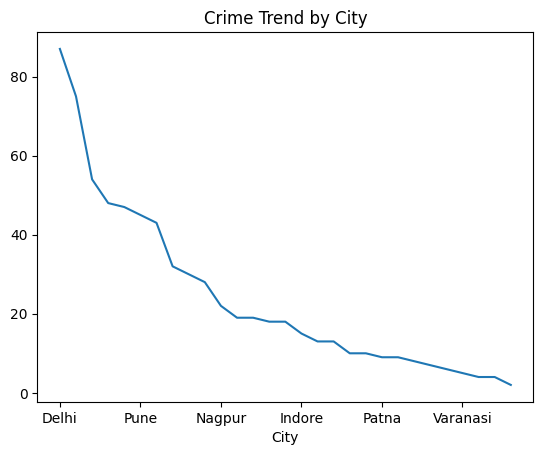

In [28]:
df['City'].value_counts().plot(kind='line')
plt.title("Crime Trend by City")
plt.show()

MULTIVARIATE ANALYSIS

1.Distribution of Crime Types Across Cities

In [27]:
df.groupby(['City', 'Crime Domain'])['Report Number'].count()

City           Crime Domain 
Agra           Fire Accident     2
               Other Crime       6
               Violent Crime     1
Ahmedabad      Fire Accident     1
               Other Crime      19
                                ..
Vasai          Other Crime       3
               Violent Crime     1
Visakhapatnam  Fire Accident     1
               Other Crime      10
               Violent Crime     2
Name: Report Number, Length: 94, dtype: int64

2.Analysis of City, Victim Gender and Crime Domain

In [26]:
df.groupby(['City', 'Victim Gender', 'Crime Domain'])['Report Number'].count()


City           Victim Gender  Crime Domain 
Agra           F              Fire Accident     2
                              Other Crime       4
                              Violent Crime     1
               M              Other Crime       2
Ahmedabad      F              Other Crime      13
                                               ..
Visakhapatnam  F              Fire Accident     1
                              Other Crime       7
                              Violent Crime     1
               M              Other Crime       3
                              Violent Crime     1
Name: Report Number, Length: 152, dtype: int64

3.Heat Map

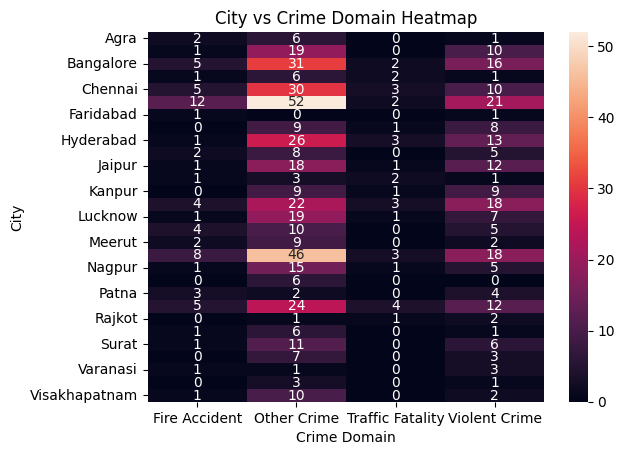

In [25]:
dfp = pd.crosstab(df['City'], df['Crime Domain'])
sns.heatmap(dfp, annot=True, fmt='d')
plt.title("City vs Crime Domain Heatmap")
plt.show()